In [1]:
import numpy as np
import ray
ray.init(num_cpus=16)
import wannierberri as wberri
from wannierberri.system import System_PythTB
from hall_ps.hall_positional_shift import HallPositionalShift

/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-14 19:32:46,660	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-14 19:32:48,771	INFO worker.py:1918 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


In [2]:
print(wberri.__version__)

26.4.5.dev4+g9192fd640


# WannierBerri PythTB

In [3]:
from ferroaxial_model import model_ferroaxial_pythtb, visualise

Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (25, 2, 2)
Real-space lattice:
 [[ 1.50000000e+00 -8.66025404e-01  0.00000000e+00]
 [-1.94289029e-16  1.73205081e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Number of wannier functions: 2
Number of R points: 25
Recommended size of FFT grid [5 5 3]
Reading the system from PythTB finished successfully
Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (25, 2, 2)
Real-space lattice:
 [[ 1.50000000e+00 -8.66025404e-01  0.00000000e+00]
 [-1.94289029e-16  1.73205081e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Number of wannier functions: 2
Number of R points: 25
Recommended size of FFT grid [5 5 3]
Reading the system from PythTB finished successfully


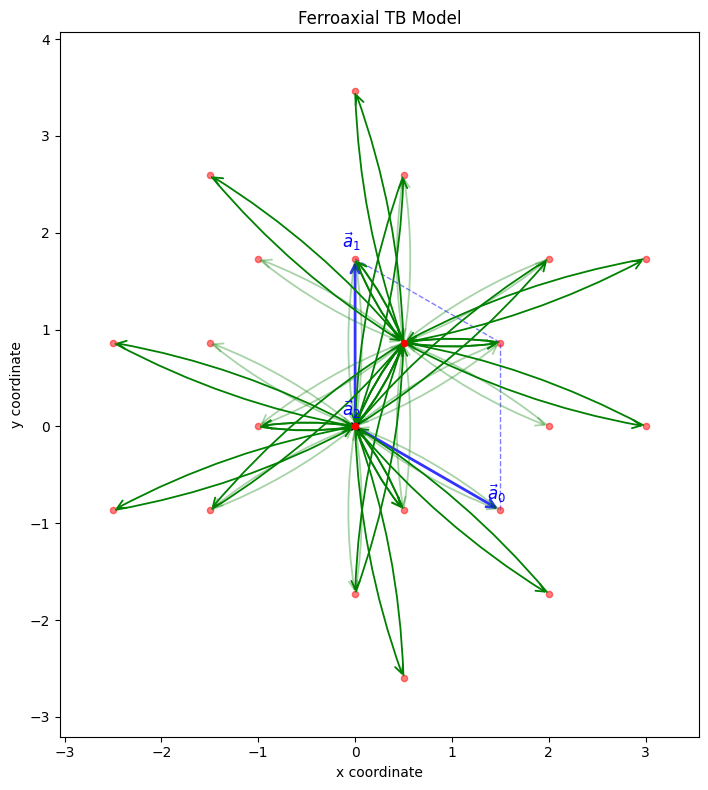

In [4]:
parameters1 = dict(mu=0.0, t=1.0, tp=0.5, Delta=1.0, t3=1.0, t2=0.25, a=1.0, c=1.0, rot_deg=-30)
model1 = model_ferroaxial_pythtb(**parameters1)
visualise(model1, title="Ferroaxial TB Model", filename="visualize_model_ferroaxial.pdf")
system_nosym = System_PythTB(model1)
system_sym = System_PythTB(model1)
system_sym.set_pointgroup(symmetry_gen=["C3z", "TimeReversal"])

# Positional Shift

In [21]:
import os


tetra = True
Efermi = np.linspace(-8, +8, 1601)

calculators = {}
calculators["hall_positional_shift_morb"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"morb_part": True, 
                                                                                                            "external_terms":False},)
calculators["hall_positional_shift_metric"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"metric_part": True, 
                                                                                                              "external_terms":False},)

os.makedirs('./output', exist_ok=True)

system = system_sym
suffix = "sym"
grid = wberri.Grid(system, NKdiv=[16,16,16], NKFFT=[8,8,8])
result_run = wberri.run(system,
        grid=grid,
        calculators = calculators,
        parallel=False,
        adpt_num_iter=10,
            fout_name=f'./output/ferroaxial-tb-TR-{suffix}',
            restart=False,
            use_irred_kpt=True,
            symmetrize=True
            )

Starting run()
Using the follwing calculators : 
############################################################

 'hall_positional_shift_morb'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x73a5e9929e80>  : calculator not described
 'hall_positional_shift_metric'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x73a61ca623c0>  : calculator not described
############################################################
Calculation on  grid - checking calculators for compatibility
hall_positional_shift_morb <hall_ps.hall_positional_shift.HallPositionalShift object at 0x73a5e9929e80>
hall_positional_shift_metric <hall_ps.hall_positional_shift.HallPositionalShift object at 0x73a61ca623c0>
All calculators are compatible
Grid is regular
The set of k points is a Grid() with NKdiv=[16 16 16], NKFFT=[8 8 8], NKtot=[128 128 128]
generating K_list
Done in 0.15619373321533203 s 
excluding symmetry-equivalent K-points from initial grid
Done in 0.05927872657775879 s 
K_

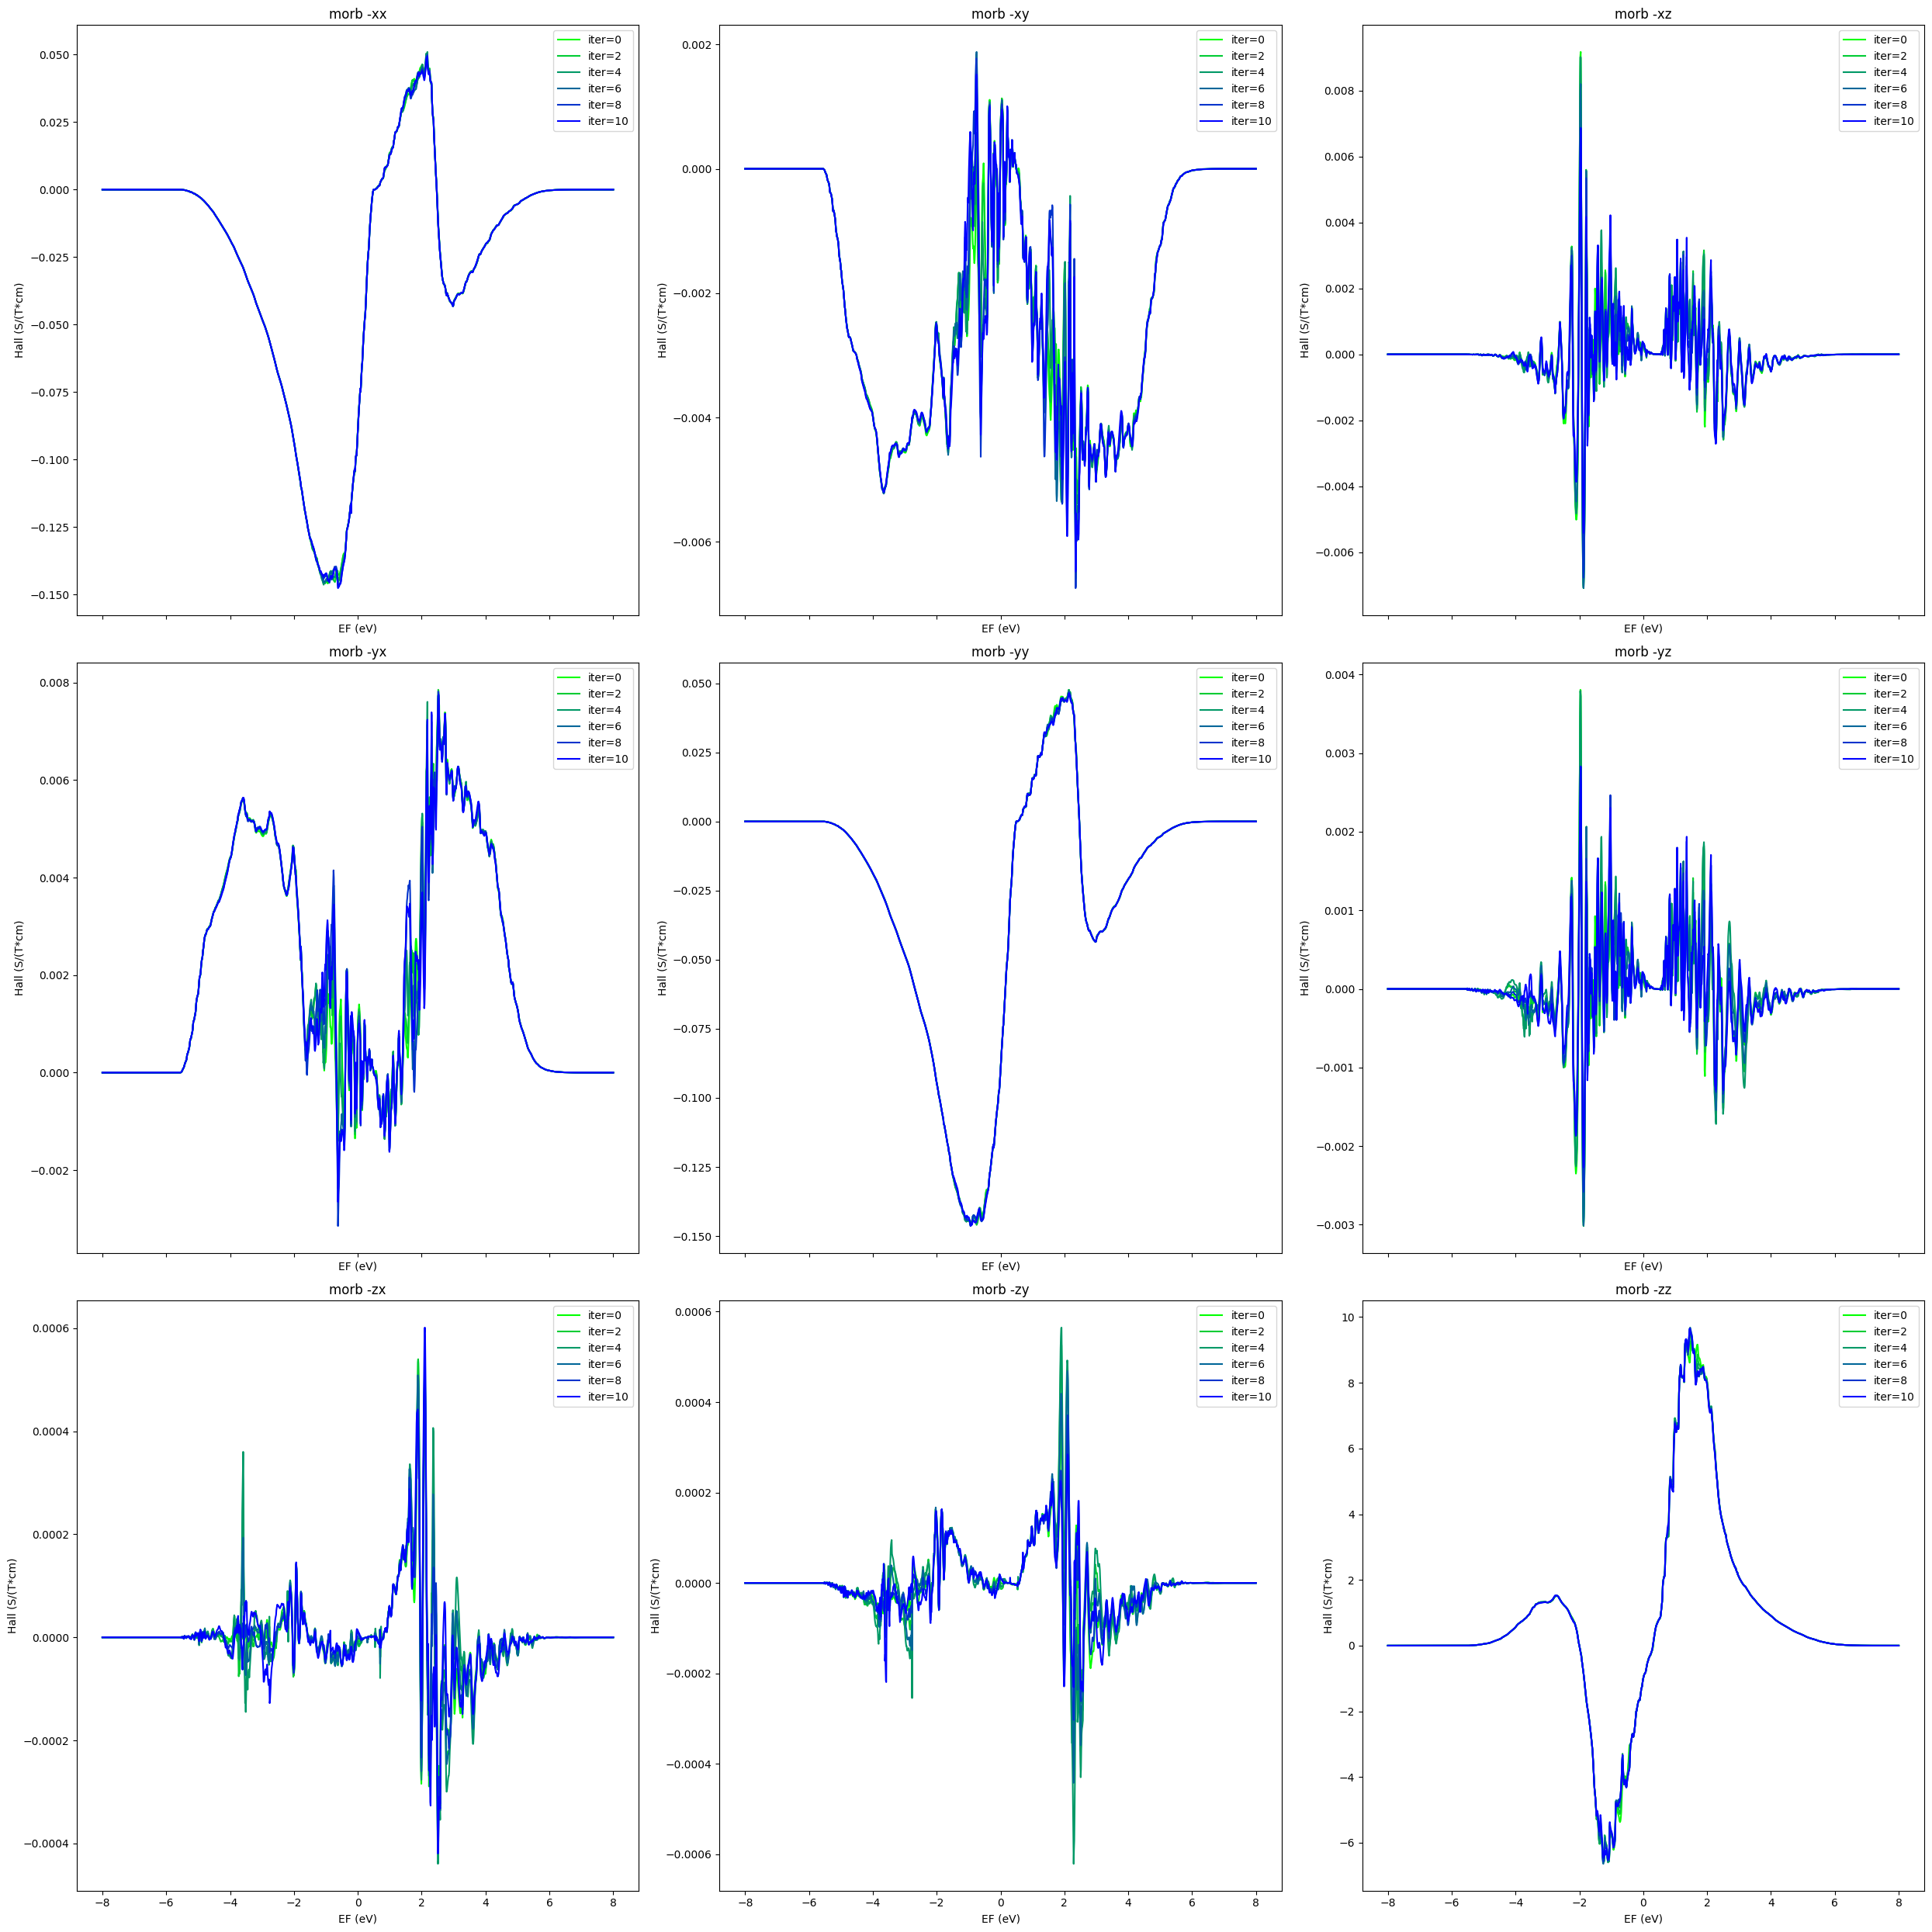

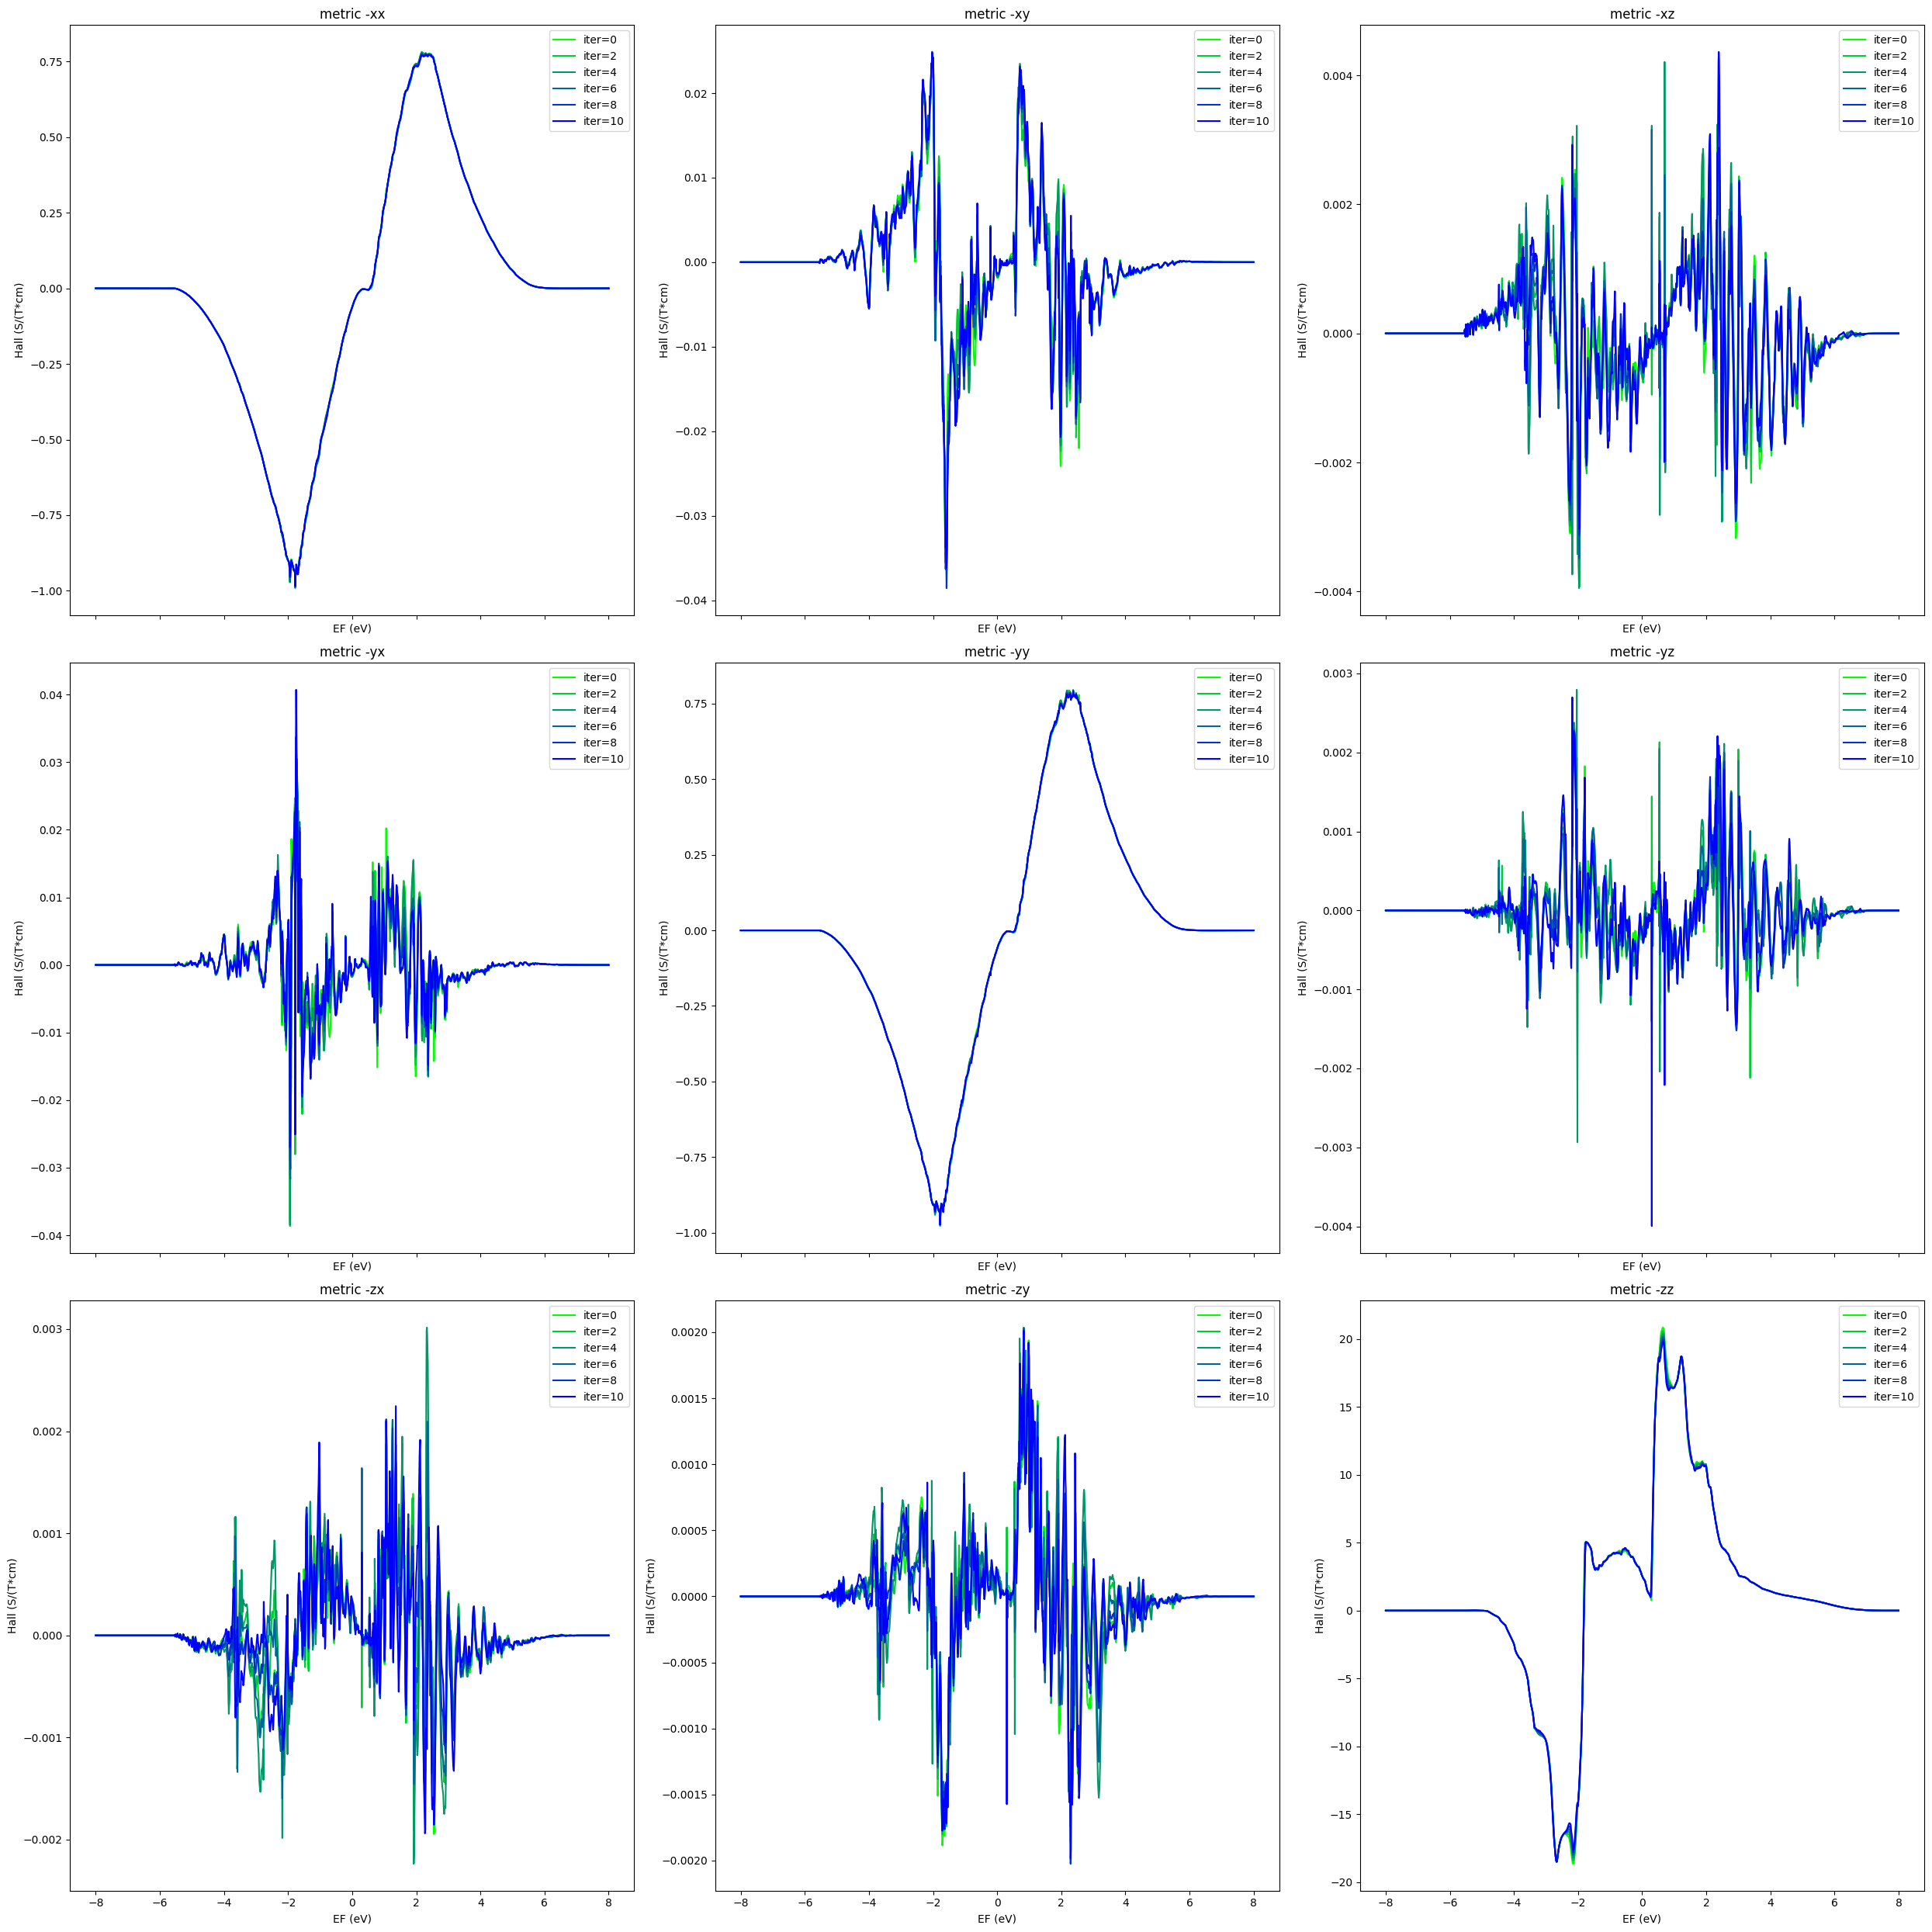

In [ ]:
from matplotlib import pyplot as plt
import numpy as np

def plot_integrated(ax, seedname, iter_start, iter_end, iter_step, suffix="", component=(0,1)):
    for i in range(iter_start, iter_end+1, iter_step):
        res_ps_morb =  np.load(f"output/{seedname}-hall_positional_shift_{suffix}_iter-{i:04d}.npz")
        Efermi = res_ps_morb['Energies_0']
        alpha = (i-iter_start)/(iter_end-iter_start)
        color = (0, 1- alpha, alpha)
        data = res_ps_morb["data"][:,*component]
        ax.plot(Efermi , data, label=f"iter={i}", color=color)
    ax.set_title(f"{seedname} convergence")
    ax.set_xlabel("EF (eV)")
    ax.set_ylabel("Hall (S/(T*cm)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{seedname}_convergence.png", dpi=300)




for term in ["morb", "metric"]:
    fig, axes = plt.subplots(3, 3, sharey=False, sharex=True, figsize=(25, 25))
    for i in range(3):
        for j in range(3):
            ax = axes[i,j]
            plot_integrated(ax, seedname="ferroaxial-tb-TR-no-sym", iter_start=0, iter_end=10, iter_step=2, suffix=term, component=(i,j))
            ax.set_title(f"{term} -{"xyz"[i]}{"xyz"[j]}")
            ax.set_xlabel("EF (eV)")
            ax.set_ylabel("Hall (S/(T*m)")
    plt.tight_layout()



In [10]:
%ls output

ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0000.dat
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0000.npz
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0001.dat
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0001.npz
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0002.dat
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0002.npz
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0003.dat
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0003.npz
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0004.dat
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0004.npz
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0005.dat
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0005.npz
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0006.dat
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0006.npz
ferroaxial-tb-TR-no-sym-hall_positional_shift_metric_iter-0007